In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Loading Dataset

In [5]:
url = "https://raw.githubusercontent.com/AshwiniJindam/SuperStore_Sales-Analysis-Python/main/Sample%20-%20Superstore.csv"
df = pd.read_csv(url, encoding='latin-1')


In [ ]:
print("Shape:", df.shape)

print(df.head())



Shape: (9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0 

In [16]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [9]:
print("Data Types:",df.dtypes)

Data Types: Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [10]:
print("Basic Statistics:", df.describe)

Basic Statistics: <bound method NDFrame.describe of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0 

# Data Cleaning

In [14]:
print("Missing Values:",df.isnull().sum())

print("\nDuplicate Values:",df.duplicated().sum())

Missing Values: Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate Values: 0


In [18]:
df.columns = df.columns.str.strip().str.replace(' ', '_')


In [19]:
# Converting data format of columns
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

print("\nCleaned Data Types:")
print(df.dtypes)


Cleaned Data Types:
Row_ID                    int64
Order_ID                    str
Order_Date       datetime64[us]
Ship_Date        datetime64[us]
Ship_Mode                   str
Customer_ID                 str
Customer_Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal_Code               int64
Region                      str
Product_ID                  str
Category                    str
Sub-Category                str
Product_Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [21]:
df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year
df['Month_Year'] = df['Order_Date'].dt.to_period('M')

print(df.dtypes)

Row_ID                    int64
Order_ID                    str
Order_Date       datetime64[us]
Ship_Date        datetime64[us]
Ship_Mode                   str
Customer_ID                 str
Customer_Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal_Code               int64
Region                      str
Product_ID                  str
Category                    str
Sub-Category                str
Product_Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Month                     int32
Year                      int32
Month_Year            period[M]
dtype: object


Exploratory Data Analysis

In [ ]:
#Sales & Profit by Region
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending= False)
print('Sales By Region:\n',sales_by_region)

#Profit by region
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending= False)
print('\nProfit By Region:\n',profit_by_region)

Sales By Region:
 Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

Profit By Region:
 Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [ ]:
#Sales & Profit by Category

sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("\nSales by Category:\n",sales_by_category)

profit_by_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print("\n Profit by Category:\n",profit_by_category)



Sales by Category:
 Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

 Profit by Category:
 Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [30]:
#Top 10 products by Sales

top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Products by Sales:")
print(top_products)


Top 10 Products by Sales:
Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [ ]:
# Bottom 10 products 
bottom_products = df.groupby('Product_Name')['Profit'].sum().sort_values(ascending=True).head(10)
print("\n Bottom 10 Products by Profit:")
print(bottom_products)


 Bottom 10 Products by Profit (Loss-makers):
Product_Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


In [32]:
# Segment analysis
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
print("\nSales by Customer Segment:")
print(segment_sales)
print("\nProfit by Customer Segment:")
print(segment_profit)


Sales by Customer Segment:
Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

Profit by Customer Segment:
Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


In [34]:
#Shipping mode analysis
shipping_analysis = df.groupby('Ship_Mode')[['Sales', 'Profit']].agg(['sum', 'mean'])
print("\nShipping Mode Analysis:")
print(shipping_analysis)


Shipping Mode Analysis:
                       Sales                   Profit           
                         sum        mean          sum       mean
Ship_Mode                                                       
First Class     3.514284e+05  228.497024   48969.8399  31.839948
Same Day        1.283631e+05  236.396179   15891.7589  29.266591
Second Class    4.591936e+05  236.089239   57446.6354  29.535545
Standard Class  1.358216e+06  227.583067  164088.7875  27.494770


In [35]:
#Discount inmaoct on Profit
discount_profit_corr = df[['Discount', 'Profit']].corr()
print("\nDiscount vs Profit Correlation:")
print(discount_profit_corr)


Discount vs Profit Correlation:
          Discount    Profit
Discount  1.000000 -0.219487
Profit   -0.219487  1.000000


In [38]:
# Monthly Sales
monthly_sales = df.groupby('Month')['Sales'].sum()
print("\nMonthly Sales Trend (First 10 months):")
print(monthly_sales)


Monthly Sales Trend (First 10 months):
Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


## Key Bussiness Insights 

In [ ]:

# Which region is most profitable?
best_region = profit_by_region.idxmax()
print(f"\nMost Profitable Region: {best_region}")
print(f" Profit: ${profit_by_region[best_region]:,.0f}")


Most Profitable Region: West
 Profit: $108,418


In [47]:
# Which product category should we focus on?
best_category = profit_by_category.idxmax()
print(f"\nMost Profitable Category: {best_category}")
print(f"   Profit: ${profit_by_category[best_category]:,.0f}")


Most Profitable Category: Technology
   Profit: $145,455


In [ ]:
# What's the profit margin?
profit_margin = (df['Profit'].sum() / df['Sales'].sum()) * 100
print(f"\nOverall Profit Margin: {profit_margin:.2f}%")


Overall Profit Margin: 12.47%


In [49]:
# Impact of discounts
high_discount_orders = df[df['Discount'] > 0.2]
low_discount_orders = df[df['Discount'] <= 0.2]
print(f"\nDiscount Impact:")
print(f"High Discount (>20%) Avg Profit: ${high_discount_orders['Profit'].mean():,.0f}")
print(f"Low Discount (≤20%) Avg Profit: ${low_discount_orders['Profit'].mean():,.0f}")
print(f" Finding: Higher discounts lead to LOWER profit!")


Discount Impact:
High Discount (>20%) Avg Profit: $-97
Low Discount (≤20%) Avg Profit: $49
 Finding: Higher discounts lead to LOWER profit!


In [50]:

# Which segment is most valuable?
best_segment = segment_profit.idxmax()
print(f"\nMost Profitable Customer Segment: {best_segment}")
print(f" Profit: ${segment_profit[best_segment]:,.0f}")


Most Profitable Customer Segment: Consumer
 Profit: $134,119


In [51]:
# Yearly Sales
yearly_growth = df.groupby('Year')['Sales'].sum()
print(f"\nYearly Sales:\n{yearly_growth}")


Yearly Sales:
Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


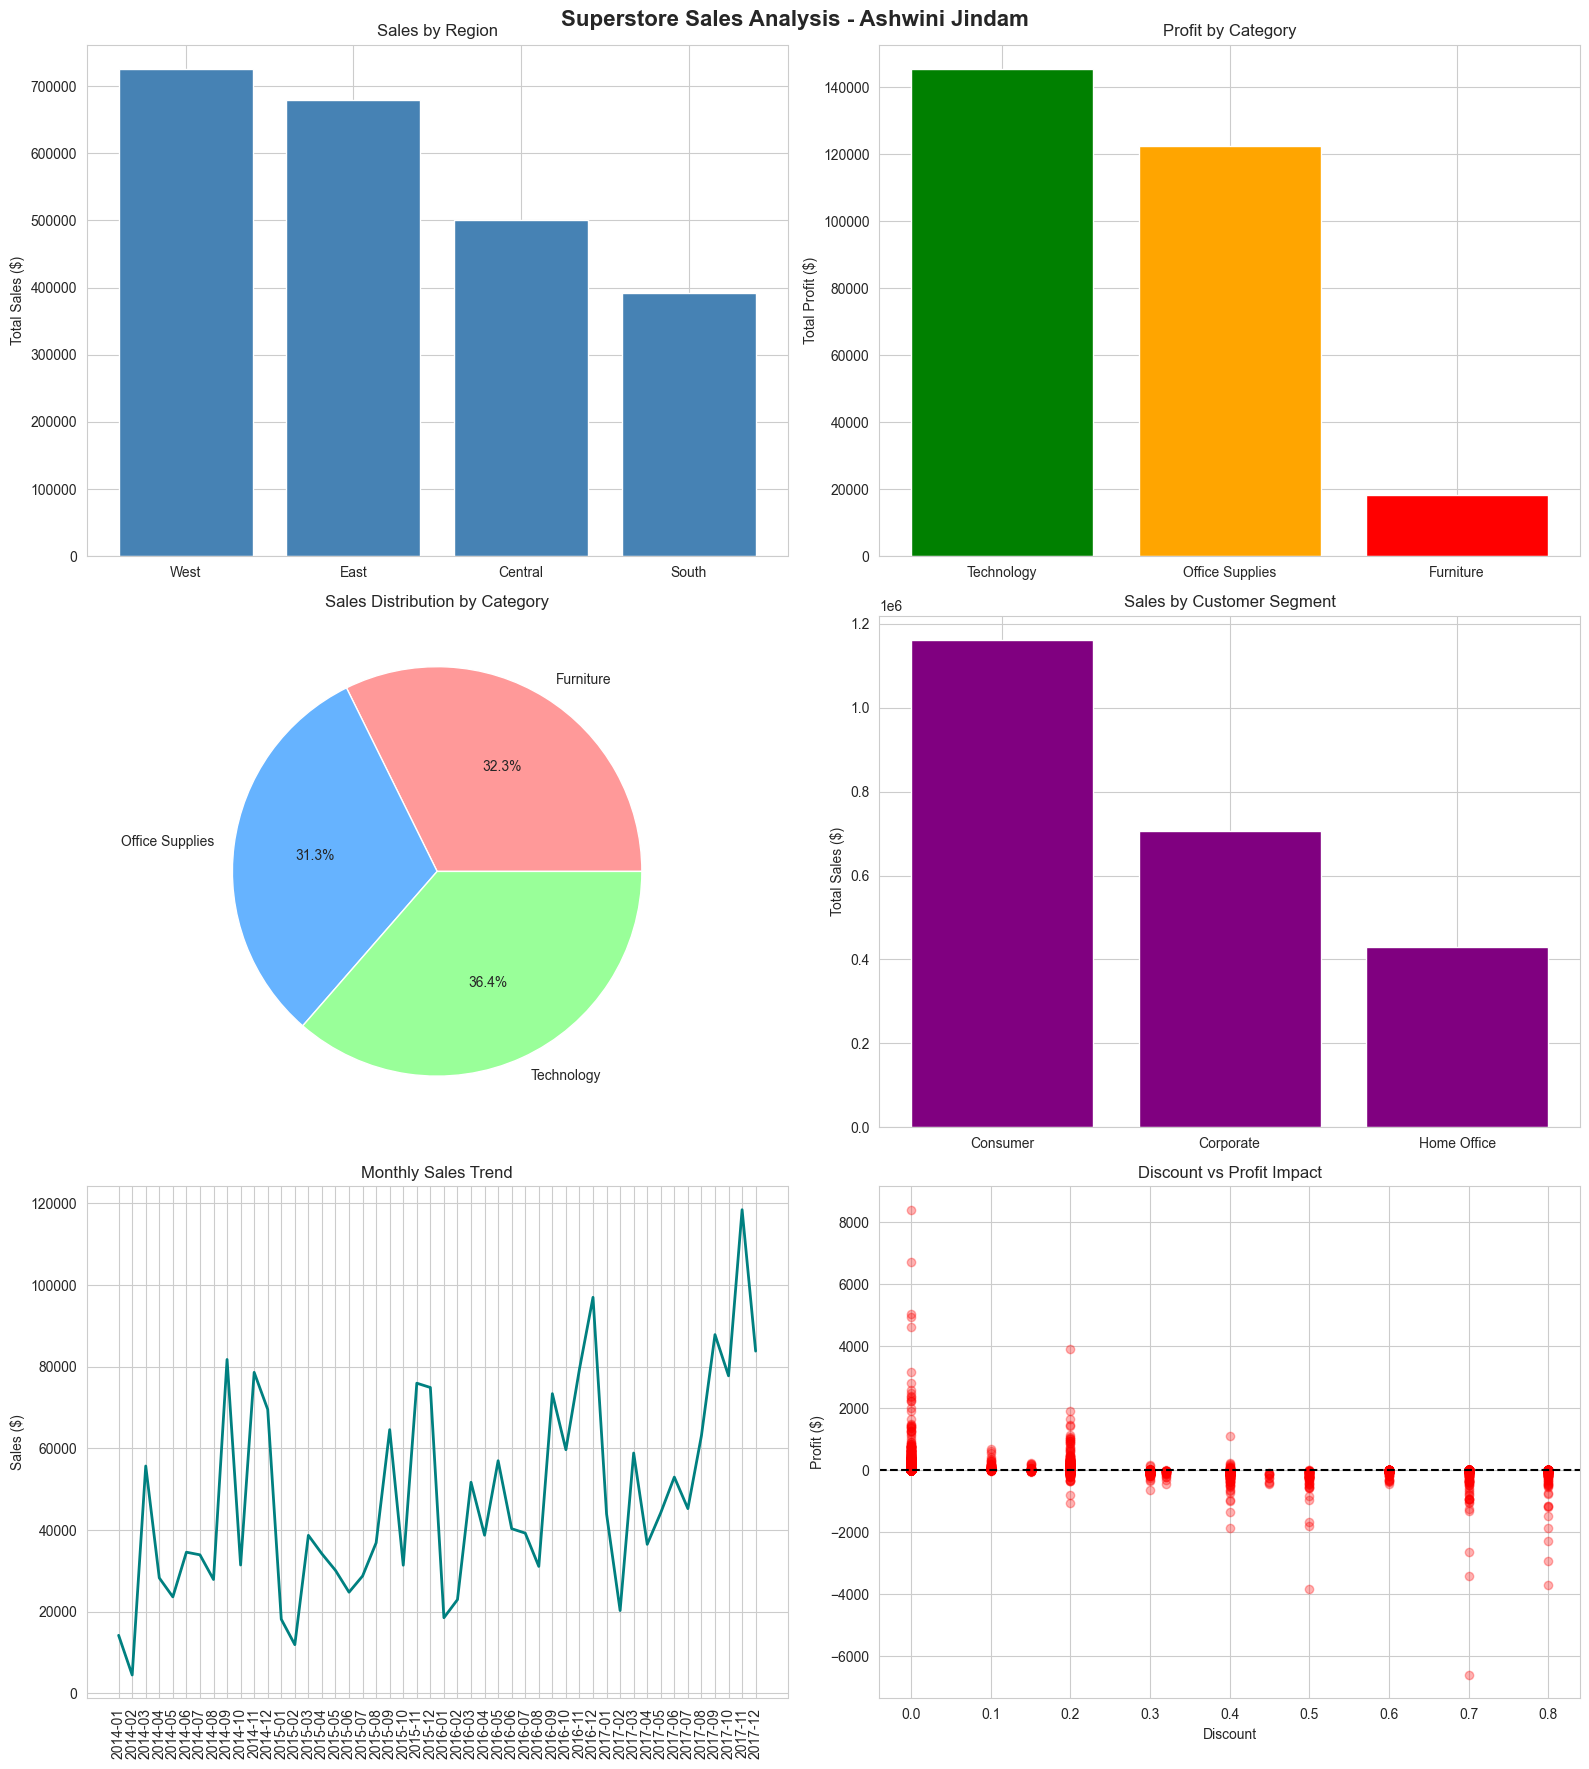

In [53]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Superstore Sales Analysis - Ashwini Jindam', fontsize=16, fontweight='bold')

# Chart 1: Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0,0].bar(region_sales.index, region_sales.values, color='steelblue')
axes[0,0].set_title('Sales by Region')
axes[0,0].set_ylabel('Total Sales ($)')

# Chart 2: Profit by Category
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
axes[0,1].bar(cat_profit.index, cat_profit.values, color=['green','orange','red'])
axes[0,1].set_title('Profit by Category')
axes[0,1].set_ylabel('Total Profit ($)')

# Chart 3: Sales Distribution by Category (Pie)
cat_sales = df.groupby('Category')['Sales'].sum()
axes[1,0].pie(cat_sales.values, labels=cat_sales.index, autopct='%1.1f%%',
              colors=['#ff9999','#66b3ff','#99ff99'])
axes[1,0].set_title('Sales Distribution by Category')

# Chart 4: Sales by Segment
seg_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
axes[1,1].bar(seg_sales.index, seg_sales.values, color='purple')
axes[1,1].set_title('Sales by Customer Segment')
axes[1,1].set_ylabel('Total Sales ($)')

# Chart 5: Monthly Sales Trend
monthly = df.groupby('Month_Year')['Sales'].sum()
axes[2,0].plot(monthly.index.astype(str), monthly.values, color='teal', linewidth=2)
axes[2,0].set_title('Monthly Sales Trend')
axes[2,0].set_ylabel('Sales ($)')
axes[2,0].tick_params(axis='x', rotation=90)

# Chart 6: Discount vs Profit Scatter
axes[2,1].scatter(df['Discount'], df['Profit'], alpha=0.3, color='red')
axes[2,1].set_title('Discount vs Profit Impact')
axes[2,1].set_xlabel('Discount')
axes[2,1].set_ylabel('Profit ($)')
axes[2,1].axhline(y=0, color='black', linestyle='--')

plt.tight_layout()
plt.savefig('superstore_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Insights

In [57]:
print(f"""
 SUPERSTORE SALES ANALYSIS - KEY INSIGHTS


1. Overall Profit Margin: {profit_margin:.2f}%

2. Best Performing Region: {best_region}
  

3. Most Profitable Category: {best_category}

4. . Discount Impact:
   High Discount Avg Profit : ${high_discount_orders['Profit'].mean():,.0f}
   Low Discount Avg Profit  : ${low_discount_orders['Profit'].mean():,.0f}

5. Yearly Sales Growth:
{yearly_growth.to_string()}


""")


 SUPERSTORE SALES ANALYSIS - KEY INSIGHTS


1. Overall Profit Margin: 12.47%

2. Best Performing Region: West


3. Most Profitable Category: Technology

4. . Discount Impact:
   High Discount Avg Profit : $-97
   Low Discount Avg Profit  : $49

5. Yearly Sales Growth:
Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552



